# Галерея аугментаций `irt_data` — kaggle & tpu

Показывает **все аугментации, доступные через наш модуль** `irt_data`
(`ObjectCropper` + `TransformPipeline` поверх albumentations, синхронно для
кадра и маски). Каждая аугментация применяется **детерминированно** (`p=1.0`,
фиксированная амплитуда) к одному репрезентативному кадру каждого домена, маска
преобразуется синхронно и показана контуром.

Пайплайн на каждый домен: сырое видео `(T,H,W)` → ROI-crop рамки объекта →
resize 256×256 → аугментация. В самом низу — проверка **temporal-синхронности**
(одинаковая геометрия на всех кадрах клипа).

In [1]:
import sys, glob
import numpy as np, scipy.io as sio
import matplotlib.pyplot as plt
from PIL import Image
ROOT='/Users/tomatocoder/Documents/thermal-control-ya-project'
sys.path.insert(0, ROOT)
from irt_data.config import ObjectCropConfig, ROI, AugConfig, AugSpec
from irt_data.crops import ObjectCropper
from irt_data.transforms import TransformPipeline
import albumentations as A
print('albumentations', A.__version__)

albumentations 2.0.8


## 1. Загрузка репрезентативного кадра + маски (kaggle, tpu)

In [2]:
GRAY2CLS = {0:0, 51:1, 102:2, 153:3, 204:4, 255:5}
def load_video(path):
    m = sio.loadmat(path)
    k = next(k for k in ('imageArray','data','IMAGES') if k in m and np.asarray(m[k]).ndim==3)
    return np.transpose(np.asarray(m[k]).astype(np.float32), (2,0,1))
def kaggle_mask(vid):
    im = np.array(Image.open(f'{ROOT}/datasets/dataset_kaggle/labels/automated_mask/{vid}.png'))
    cls = np.zeros_like(im, np.uint8)
    for g,c in GRAY2CLS.items(): cls[im==g]=c
    return cls
def tpu_base_mask():
    a = np.array(Image.open(f'{ROOT}/datasets/dataset_tpu/base_mask.png'))
    g = a[...,1] if a.ndim==3 else a
    return (g>0).astype(np.uint8)

def prep(domain):
    if domain=='kaggle':
        pth = sorted(glob.glob(f'{ROOT}/datasets/dataset_kaggle/data/*.mat'))[0]
        vid = load_video(pth); roi = ROI(80,25,178,190)
        mask = kaggle_mask(pth.split('/')[-1].replace('.mat',''))
    else:
        pth = sorted(glob.glob(f'{ROOT}/datasets/dataset_tpu/*.mat'))[0]
        vid = load_video(pth); roi = ROI(80,43,178,120)
        mask = tpu_base_mask()
    peak = int(vid.reshape(vid.shape[0],-1).mean(1).argmax())
    cr = ObjectCropper(ObjectCropConfig(enabled=True, roi=roi, output_size=(256,256), pad_mode='reflect'))
    box = cr.box_for(vid.shape[1], vid.shape[2], meta=None)
    frame = cr.apply_image(vid[peak][...,None], box).astype(np.float32)  # (256,256,1)
    m = cr.apply_mask(mask, box)                                          # (256,256)
    return frame, m, vid, roi, cr, box, peak

DATA = {d: prep(d) for d in ('kaggle','tpu')}
for d,(f,m,*_ ) in DATA.items():
    print(d, 'frame', f.shape, 'mask uniq', np.unique(m))

kaggle frame (256, 256, 1) mask uniq [0 2 3 4]
tpu frame (256, 256, 1) mask uniq [0 1]


## 2. Каталог аугментаций модуля

`TransformPipeline` строит любую albumentations-трансформацию по `AugSpec(name, params)`
плюс кастомную `DiscreteRotate7` (детерминированный поворот ±7°). Ниже —
детерминированные версии (амплитуда фиксирована, `p=1.0`), сгруппированные по типу.
Несовместимые с версией albumentations просто помечаются как skip.

In [3]:
CATALOG = [
  ('Original', None),
  # — геометрия (флипы/повороты 90) —
  ('HorizontalFlip', [AugSpec('HorizontalFlip', {'p':1.0})]),
  ('VerticalFlip', [AugSpec('VerticalFlip', {'p':1.0})]),
  ('Transpose', [AugSpec('Transpose', {'p':1.0})]),
  ('RandomRotate90', [AugSpec('RandomRotate90', {'p':1.0})]),
  # — кастомная из модуля —
  ('DiscreteRotate7 (+7deg)', [AugSpec('DiscreteRotate7', {'p':1.0})]),
  # — аффинные / повороты на угол —
  ('Rotate 30deg', [AugSpec('Rotate', {'limit':(30,30),'border_mode':4,'p':1.0})]),
  ('Affine shift+scale+shear', [AugSpec('Affine', {'translate_percent':0.1,'scale':1.15,'shear':10,'p':1.0})]),
  # — эластичные / дисторсии —
  ('ElasticTransform', [AugSpec('ElasticTransform', {'alpha':40,'sigma':6,'p':1.0})]),
  ('GridDistortion', [AugSpec('GridDistortion', {'num_steps':5,'distort_limit':0.3,'p':1.0})]),
  ('OpticalDistortion', [AugSpec('OpticalDistortion', {'distort_limit':0.4,'p':1.0})]),
  ('Perspective', [AugSpec('Perspective', {'scale':(0.08,0.12),'p':1.0})]),
  # — окклюзия / дропаут —
  ('CoarseDropout', [AugSpec('CoarseDropout', {'p':1.0})]),
  ('GridDropout', [AugSpec('GridDropout', {'ratio':0.4,'p':1.0})]),
  # — интенсивность (только к кадру; маска не трогается) —
  ('RandomBrightnessContrast', [AugSpec('RandomBrightnessContrast', {'brightness_limit':0.4,'contrast_limit':0.4,'p':1.0})]),
  ('RandomGamma', [AugSpec('RandomGamma', {'gamma_limit':(60,140),'p':1.0})]),
  ('GaussNoise', [AugSpec('GaussNoise', {'p':1.0})]),
  ('GaussianBlur', [AugSpec('GaussianBlur', {'blur_limit':(5,7),'p':1.0})]),
  # — стандартный боевой набор (как в make_augmented_dataset.py) —
  ('STANDARD hflip+vflip+rot90', [AugSpec('HorizontalFlip',{'p':1.0}), AugSpec('VerticalFlip',{'p':1.0}), AugSpec('RandomRotate90',{'p':1.0})]),
]
print(len(CATALOG)-1, 'аугментаций в каталоге + Original')

18 аугментаций в каталоге + Original


## 3. Галерея — kaggle и tpu

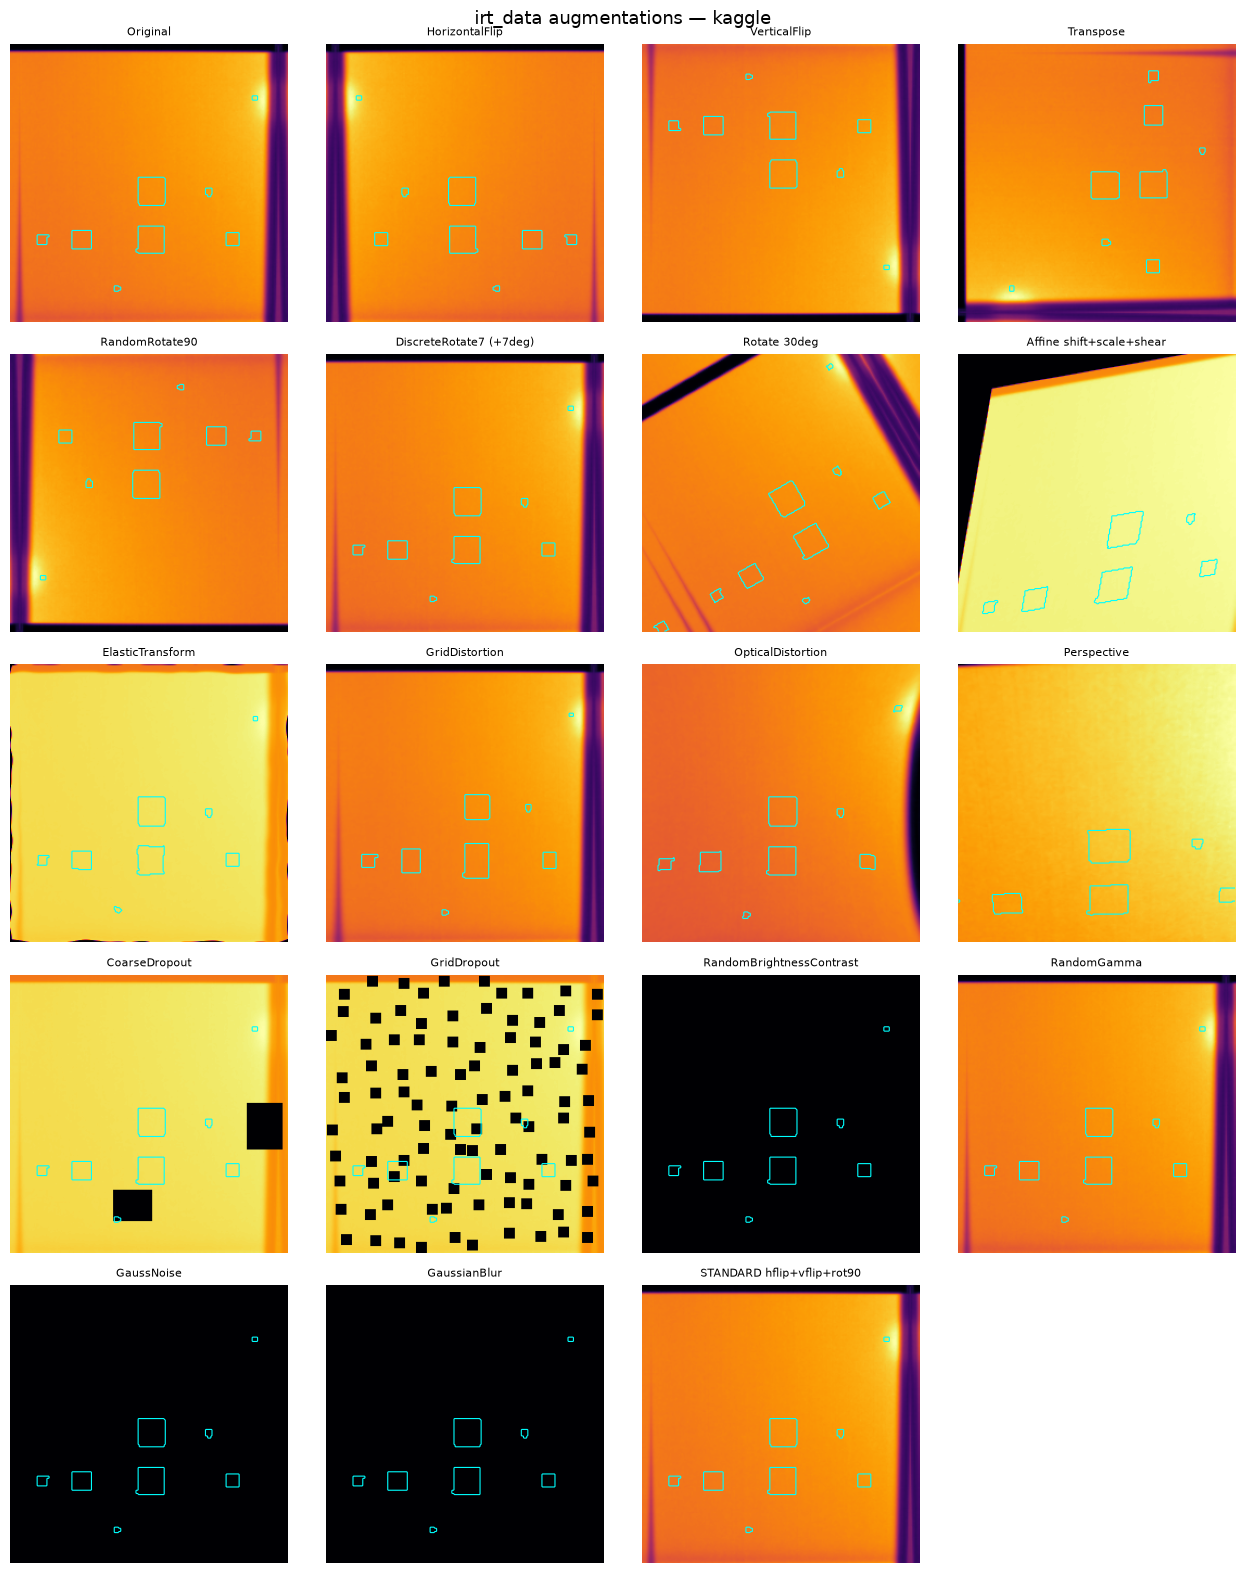

In [4]:
import random
def apply_one(frame, mask, specs):
    if specs is None:
        return frame, mask, 'ok'
    try:
        random.seed(67); np.random.seed(67)
        pipe = TransformPipeline(AugConfig(spatial=specs))
        fa, ma = pipe.apply_features(frame, mask)
        return np.asarray(fa), (np.asarray(ma) if ma is not None else mask), 'ok'
    except Exception as e:
        return frame, mask, f'skip: {type(e).__name__}'

def gallery(domain):
    frame, mask, *_ = DATA[domain]
    n = len(CATALOG); cols = 4; rows = (n+cols-1)//cols
    fig, axs = plt.subplots(rows, cols, figsize=(3.2*cols, 3.2*rows))
    for ax,(name,specs) in zip(axs.flat, CATALOG):
        fa, ma, status = apply_one(frame, mask, specs)
        img = np.asarray(fa)[...,0] if np.asarray(fa).ndim==3 else np.asarray(fa)
        ax.imshow(img, cmap='inferno')
        if ma is not None and np.any(ma>0):
            ax.contour(np.asarray(ma)>0, colors='cyan', linewidths=0.8)
        ttl = name if status=='ok' else f'{name}\n[{status}]'
        ax.set_title(ttl, fontsize=8); ax.axis('off')
    for ax in axs.flat[n:]: ax.axis('off')
    fig.suptitle(f'irt_data augmentations — {domain}', fontsize=13)
    plt.tight_layout(); plt.show()

gallery('kaggle')

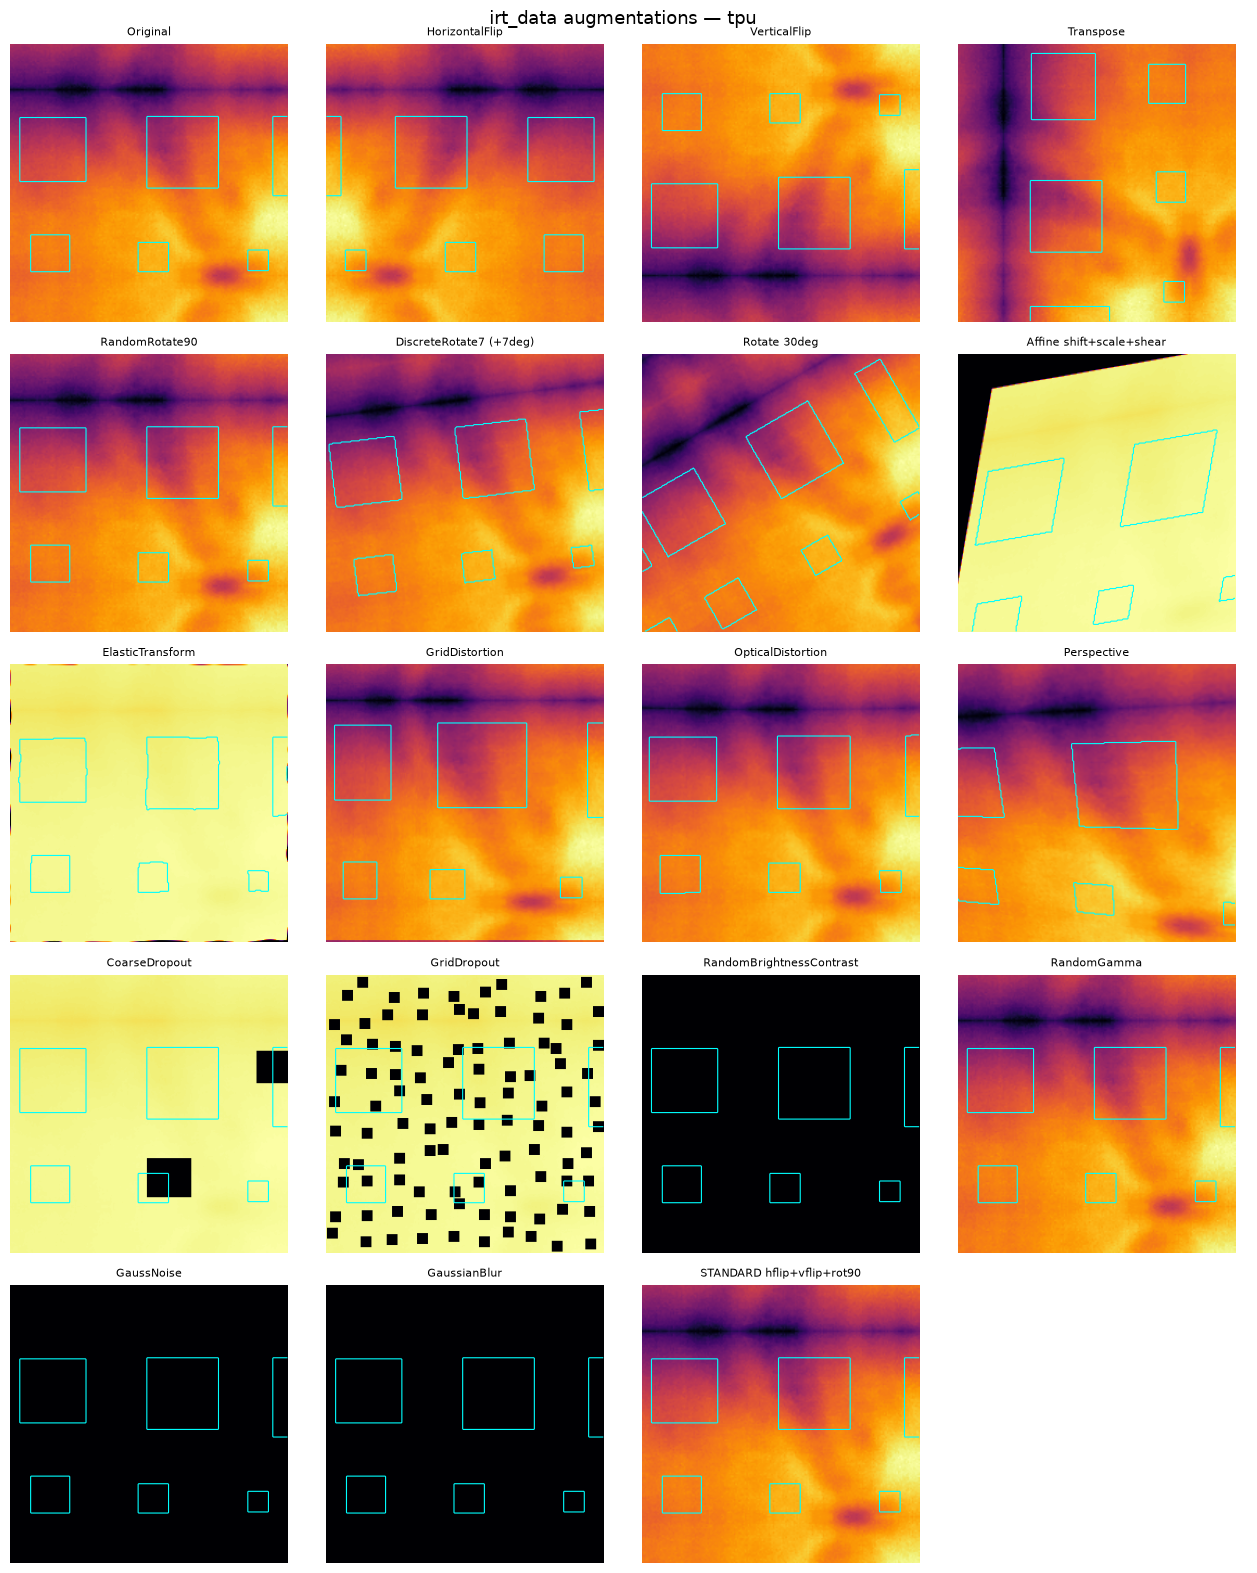

In [5]:
gallery('tpu')

## 4. Temporal-синхронность: одна геометрия на все кадры клипа

Ключевое свойство модуля — при аугментации **видео** (не одиночного кадра)
геометрия применяется **идентично ко всем кадрам** и к маске (`apply_temporal`,
`use_replay_fallback=True`). Проверяем: берём несколько кадров, аугментируем клип
целиком и показываем, что сдвиг/поворот одинаков во времени.

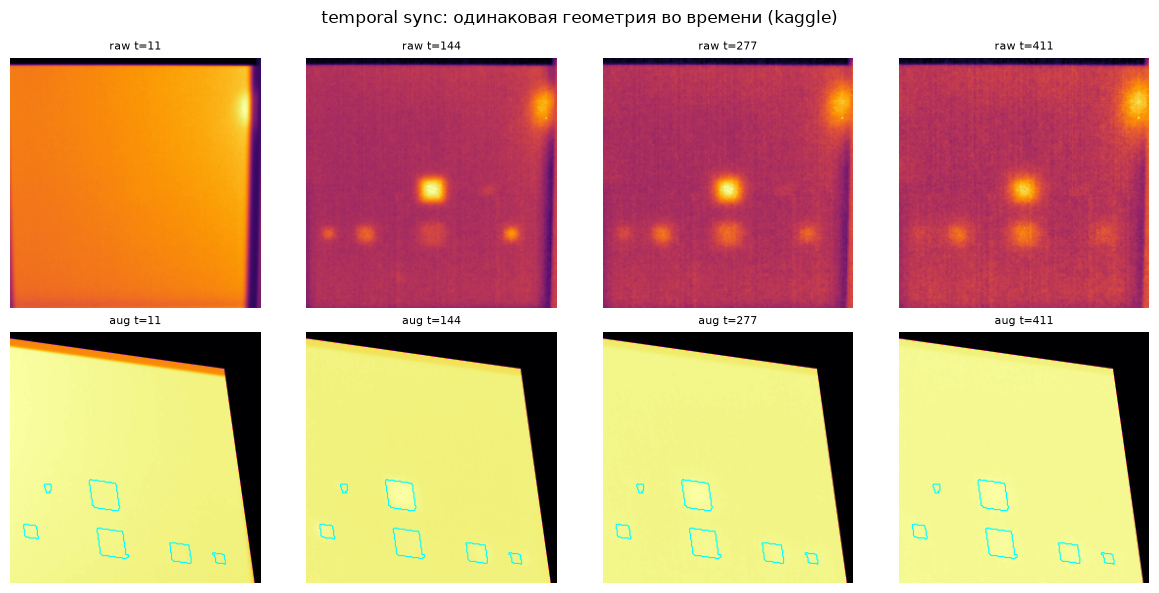

форма аугментированного клипа: (4, 256, 256) | маска: (256, 256)


In [6]:
frame, mask, vid, roi, cr, box, peak = DATA['kaggle']
from irt_data.crops import apply_crop_thw, resize_2d
idxs = np.linspace(peak, min(peak+400, vid.shape[0]-1), 4).astype(int)
clip = apply_crop_thw(vid[idxs], box, 'reflect')
clip = np.stack([resize_2d(f, (256,256), is_mask=False) for f in clip])
specs = [AugSpec('Affine', {'translate_percent':0.12,'scale':1.1,'shear':8,'p':1.0}), AugSpec('HorizontalFlip',{'p':1.0})]
random.seed(1); np.random.seed(1)
pipe = TransformPipeline(AugConfig(spatial=specs, use_replay_fallback=True))
clip_a, mask_a = pipe.apply_temporal(clip, mask)
fig, axs = plt.subplots(2, len(idxs), figsize=(3*len(idxs), 6))
for j,fr in enumerate(idxs):
    axs[0,j].imshow(clip[j], cmap='inferno'); axs[0,j].set_title(f'raw t={fr}', fontsize=8); axs[0,j].axis('off')
    axs[1,j].imshow(clip_a[j], cmap='inferno')
    axs[1,j].contour(np.asarray(mask_a)>0, colors='cyan', linewidths=0.8)
    axs[1,j].set_title(f'aug t={fr}', fontsize=8); axs[1,j].axis('off')
axs[0,0].set_ylabel('до'); axs[1,0].set_ylabel('после')
fig.suptitle('temporal sync: одинаковая геометрия во времени (kaggle)', fontsize=12)
plt.tight_layout(); plt.show()
print('форма аугментированного клипа:', np.asarray(clip_a).shape, '| маска:', np.asarray(mask_a).shape)

## Итог

- Модуль `irt_data` строит **любую** albumentations-аугментацию через
  `AugSpec(name, params)` + кастомную `DiscreteRotate7`; выше показан весь
  каталог (геометрия, аффинные, эластичные/дисторсии, окклюзия, интенсивность,
  стандартный боевой набор) на репрезентативных кадрах **kaggle** и **tpu**.
- Геометрические аугментации применяются **синхронно к кадру и маске**;
  интенсивностные — только к кадру.
- `apply_temporal` гарантирует **одинаковую геометрию по всем кадрам** клипа —
  критично для термо-последовательностей (TSR/PPT считаются уже поверх).
- Боевой пайплайн проекта (`make_augmented_dataset.py`): `HorizontalFlip +
  VerticalFlip + RandomRotate90` с `use_replay_fallback=True`.